Model Optimization & Imbalance Handling (LB30)

**Tujuan:** Meningkatkan kemampuan model LB30 (lookback=30) dalam mengenali kelas minoritas dan meningkatkan Macro F1, melalui:
- **Tahap 12A:** membandingkan `SparseCategoricalCrossentropy + class_weight` (MODEL_A / baseline) vs `Weighted Focal Loss + class_weight` (MODEL_B / focal)
- **Tahap 12B:** Optuna hyperparameter search (30 trial) menggunakan loss terbaik dari 12A

Split data, fitur (8: RR, Tavg, RH, CIN, KINDEX, LI, TT, SWEAT), label (4 kelas: 0=Rendah, 1=Sedang, 2=Tinggi, 3=Sangat Tinggi), dan lookback (=30) **tidak diubah** dari Stage 11.

## Asumsi & Keputusan Desain (dikonfirmasi dengan pengguna)

1. **Weighted Focal Loss** diimplementasikan sebagai *focal modulating factor* `(1 - p_t)^gamma` terhadap cross-entropy, **tanpa** faktor `alpha` internal per-kelas — pembobotan kelas sepenuhnya diserahkan ke parameter `class_weight` bawaan Keras pada `.fit()` (dikalikan ke loss per-sampel oleh Keras setelah loss function mengembalikan nilai per-sampel). Ini menghindari pembobotan ganda (double counting) antara `alpha` internal focal loss dan `class_weight` eksternal, sekaligus membuat perbandingan MODEL_A vs MODEL_B adil: **satu-satunya perbedaan adalah bentuk loss (CE vs focal-modulated CE)**, sedangkan pembobotan kelas (`class_weight`) identik untuk keduanya.
2. **gamma = 2.0** (nilai standar pada literatur Focal Loss, Lin et al. 2017).
3. **Dropout Optuna:** search space menyediakan satu parameter `dropout` (bukan `dropout1`/`dropout2` terpisah), sehingga nilai yang sama dipakai untuk kedua `Dropout` layer.
4. File `confusion_matrix_validation.csv` dan `confusion_matrix_test.csv` (nama generik, sesuai daftar output) merepresentasikan confusion matrix dari **model akhir/terbaik (tuned model, Tahap 12B)**. Confusion matrix baseline dan focal tetap dihitung dan divisualisasikan di notebook (Bagian 10) untuk keperluan analisis Tahap 12A, dan turut disimpan dengan nama eksplisit (`confusion_matrix_baseline_*.csv`, `confusion_matrix_focal_*.csv`) sebagai pelengkap non-wajib.


In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 30.6 MB/s eta 0:00:00


## 1. Import Library

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from imblearn.over_sampling import RandomOverSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

import optuna
from optuna.samplers import TPESampler

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "."    # ganti sesuai lokasi file .npy Anda
OUTPUT_DIR = "."  # ganti sesuai lokasi output yang diinginkan

FEATURES = ["RR", "Tavg", "RH", "CIN", "KINDEX", "LI", "TT", "SWEAT"]
N_CLASSES = 4
CLASS_NAMES = ["Rendah", "Sedang", "Tinggi","Sangat Tinggi"]
LOOKBACK = 30

print("TensorFlow version:", tf.__version__)
print("Optuna version:", optuna.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
Optuna version: 4.9.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load Dataset (LB30)

Memuat artefak Stage 10/11 untuk lookback=30. Nama file dicoba dengan dua konvensi (huruf besar/kecil) agar kompatibel dengan penamaan sebelumnya (`X_train_LB30.npy`) maupun penamaan pada instruksi Stage 12 (`X_train_lb30.npy`).

In [3]:
def resolve_path(*candidates):
    for c in candidates:
        p = os.path.join(DATA_DIR, c)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Tidak ditemukan salah satu dari: {candidates}")

X_train = np.load(resolve_path("X_train_lb30.npy", "X_train_LB30.npy"))
y_train = np.load(resolve_path("y_train_lb30.npy", "y_train_LB30.npy"))
X_val   = np.load(resolve_path("X_val_lb30.npy", "X_validation_lb30.npy", "X_validation_LB30.npy"))
y_val   = np.load(resolve_path("y_val_lb30.npy", "y_validation_lb30.npy", "y_validation_LB30.npy"))
X_test  = np.load(resolve_path("X_test_lb30.npy", "X_test_LB30.npy"))
y_test  = np.load(resolve_path("y_test_lb30.npy", "y_test_LB30.npy"))

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)

X_train: (1592, 30, 8) y_train: (1592,)
X_val:   (268, 30, 8) y_val:   (268,)
X_test:  (223, 30, 8) y_test:  (223,)


## 3. Audit Dataset

In [4]:
assert X_train.shape[1] == LOOKBACK, "Lookback X_train tidak sesuai (harus tetap 30)"
assert X_train.shape[2] == len(FEATURES), "Jumlah fitur tidak sesuai (harus tetap 8)"

audit_rows = []
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    audit_rows.append({
        "split": name,
        "n_samples": X.shape[0],
        "timesteps": X.shape[1],
        "n_features": X.shape[2],
        "X_dtype": str(X.dtype),
        "y_dtype": str(y.dtype),
        "X_min": float(np.nanmin(X)),
        "X_max": float(np.nanmax(X)),
        "n_nan_X": int(np.isnan(X).sum()),
    })

audit_df = pd.DataFrame(audit_rows)
audit_df

,split,n_samples,timesteps,n_features,X_dtype,y_dtype,X_min,X_max,n_nan_X
0,train,1592,30,8,float64,int64,0.000000,1.000000,0
1,val,268,30,8,float64,int64,-1.111491,7.476681,0
2,test,223,30,8,float64,int64,0.000000,1.504234,0


## 4. Distribusi Kelas

In [5]:
dist_rows = []
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    vals, counts = np.unique(y, return_counts=True)
    row = {"split": name, "n_total": len(y)}
    for c in range(N_CLASSES):
        row[CLASS_NAMES[c]] = int(counts[vals == c][0]) if c in vals else 0
    dist_rows.append(row)

class_dist_df = pd.DataFrame(dist_rows)
class_dist_df

,split,n_total,Rendah,Sedang,Tinggi,Sangat Tinggi
0,train,1592,1285,193,91,23
1,val,268,222,27,14,5
2,test,223,174,26,20,3


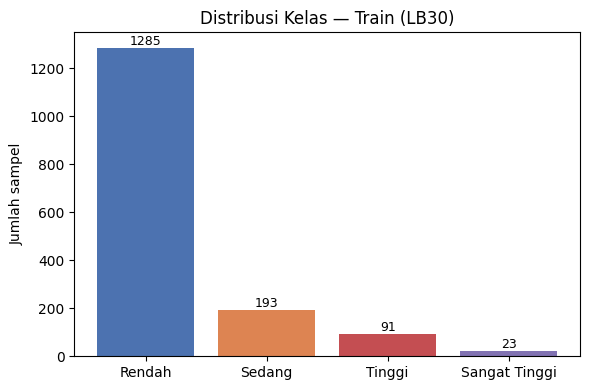

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = [class_dist_df.loc[class_dist_df.split == "train", c].values[0] for c in CLASS_NAMES]
bars = ax.bar(CLASS_NAMES, counts, color=["#4C72B0", "#DD8452", "#C44E52", "#8172B2"])
ax.set_title("Distribusi Kelas — Train (LB30)")
ax.set_ylabel("Jumlah sampel")
for b, v in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, v + max(counts)*0.01, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "4_class_distribution_train.png"), dpi=150)
plt.show()

## 5. Hitung Class Weight

In [7]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
for c in range(N_CLASSES):
    class_weight_dict.setdefault(c, 1.0)

print("class_weight (dari y_train_lb30):", class_weight_dict)

class_weight (dari y_train_lb30): {0: 0.309727626459144, 1: 2.062176165803109, 2: 4.373626373626373, 3: 17.304347826086957}


## 5b. Alpha-Weighted Focal Loss — Hitung Alpha dari Distribusi Kelas Train

Alpha dihitung otomatis dari `y_train` (sebelum oversampling) menggunakan **inverse class frequency yang dinormalisasi** (sum(alpha) = 1). Alpha ini akan dipakai sebagai bobot internal di dalam Weighted Focal Loss (Bagian 6), terpisah dari `class_weight` yang sudah ada.

In [8]:
# Alpha-Weighted Focal Loss: hitung alpha dari distribusi kelas y_train (inverse class frequency, dinormalisasi)
train_classes, train_counts = np.unique(y_train, return_counts=True)
counts_per_class = np.zeros(N_CLASSES)
for c, cnt in zip(train_classes, train_counts):
    counts_per_class[c] = cnt

inv_freq = 1.0 / counts_per_class
alpha_focal = inv_freq / inv_freq.sum()  # dinormalisasi agar sum(alpha) = 1

print("Jumlah sampel per kelas (y_train, sebelum oversampling):", counts_per_class)
print("Alpha (inverse class frequency, dinormalisasi):", alpha_focal)

Jumlah sampel per kelas (y_train, sebelum oversampling): [1285.  193.   91.   23.]
Alpha (inverse class frequency, dinormalisasi): [0.01287855 0.08574581 0.18185649 0.71951915]


## 5c. RandomOverSampler (Train Only)

Oversampling hanya diterapkan pada data **training** (setelah data dimuat, sebelum `model.fit()`). `X_train` berbentuk sequence 3D `(samples, timesteps, features)`, sehingga di-reshape ke 2D untuk `RandomOverSampler`, lalu dikembalikan lagi ke bentuk sequence 3D dengan `timesteps = LOOKBACK (30)` yang tetap sama. `X_val`/`y_val` dan `X_test`/`y_test` **tidak diubah**.

In [9]:
# RandomOverSampler — hanya pada data training, sebelum model.fit()
n_samples, n_timesteps, n_features = X_train.shape
X_train_2d = X_train.reshape(n_samples, n_timesteps * n_features)

ros = RandomOverSampler(random_state=SEED)
X_train_2d_res, y_train_res = ros.fit_resample(X_train_2d, y_train)

# Kembalikan ke bentuk sequence LSTM (samples, timesteps, features) — lookback tetap 30
X_train_res = X_train_2d_res.reshape(-1, n_timesteps, n_features)

assert X_train_res.shape[1] == LOOKBACK, "Lookback X_train_res tidak sesuai (harus tetap 30) setelah oversampling"
assert X_train_res.shape[2] == len(FEATURES), "Jumlah fitur X_train_res tidak sesuai setelah oversampling"
assert X_train_res.shape[0] == y_train_res.shape[0], "Jumlah sampel X_train_res dan y_train_res tidak sinkron"

print("Sebelum RandomOverSampler:", X_train.shape, y_train.shape)
print("Sesudah RandomOverSampler: ", X_train_res.shape, y_train_res.shape)

# X_train & y_train diganti ke versi hasil oversampling untuk seluruh training selanjutnya (Bagian 7 dst.)
# X_val/y_val dan X_test/y_test TIDAK diubah.
X_train, y_train = X_train_res, y_train_res

Sebelum RandomOverSampler: (1592, 30, 8) (1592,)
Sesudah RandomOverSampler:  (5140, 30, 8) (5140,)


## 6. Fungsi Bantu: Arsitektur Model, Weighted Focal Loss, dan Metrik Evaluasi

In [10]:
def build_model(input_shape, units1=64, units2=32, dropout=0.2,
                 learning_rate=0.001, loss=None, n_classes=N_CLASSES):
    model = Sequential([
        LSTM(units1, return_sequences=True, input_shape=input_shape),
        Dropout(dropout),
        LSTM(units2),
        Dropout(dropout),
        Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=loss,
        metrics=["accuracy"],
    )
    return model

def sparse_categorical_focal_loss(gamma=2.0, alpha=None, n_classes=N_CLASSES):
    """Alpha-Weighted Focal Loss (per-sampel).

    - `gamma`: faktor modulasi focal loss (tetap 2.0, tidak diubah).
    - `alpha`: array/list sepanjang n_classes berisi bobot internal per kelas
      (mis. hasil inverse class frequency yang dinormalisasi dari `y_train`,
      lihat Bagian 5b). Jika `alpha=None`, perilaku identik dengan versi
      sebelumnya (semua kelas berbobot 1 di dalam loss), sehingga pembobotan
      kelas sepenuhnya berasal dari argumen `class_weight` pada model.fit().
      Jika `alpha` diberikan, setiap kelas mendapat bobot internal tambahan
      di dalam loss function itu sendiri.
    """
    if alpha is None:
        alpha_tensor = tf.ones(n_classes, dtype=tf.float32)
    else:
        alpha_tensor = tf.constant(alpha, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true_onehot = tf.one_hot(y_true, depth=n_classes)
        ce = -y_true_onehot * tf.math.log(y_pred)
        modulating_factor = tf.pow(1.0 - y_pred, gamma)
        alpha_weight = tf.reshape(alpha_tensor, [1, n_classes])
        fl = alpha_weight * modulating_factor * ce  # bobot alpha per kelas diterapkan di sini
        return tf.reduce_sum(fl, axis=-1)  # shape (batch,) -- per-sample loss
    return loss_fn

def get_callbacks():
    return [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
    ]

def compute_pod_far_csi(cm):
    """POD/FAR/CSI per kelas (one-vs-rest) dari confusion matrix, macro-average."""
    n_classes = cm.shape[0]
    pod_list, far_list, csi_list = [], [], []
    for c in range(n_classes):
        TP = cm[c, c]
        FN = cm[c, :].sum() - TP
        FP = cm[:, c].sum() - TP
        pod_list.append(TP / (TP + FN) if (TP + FN) > 0 else 0.0)
        far_list.append(FP / (TP + FP) if (TP + FP) > 0 else 0.0)
        csi_list.append(TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0.0)
    return {
        "POD_macro": float(np.mean(pod_list)),
        "FAR_macro": float(np.mean(far_list)),
        "CSI_macro": float(np.mean(csi_list)),
    }

def evaluate_split(model, X, y, n_classes=N_CLASSES):
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average="macro", zero_division=0)
    rec = recall_score(y, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y, y_pred, labels=list(range(n_classes)))
    pfc = compute_pod_far_csi(cm)
    metrics = {"Accuracy": acc, "Precision_Macro": prec, "Recall_Macro": rec, "F1_Macro": f1, **pfc}
    return metrics, cm, y_pred

def save_cm_csv(cm, path, class_names=CLASS_NAMES):
    cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in class_names],
                              columns=[f"pred_{c}" for c in class_names])
    cm_df.to_csv(path)
    return cm_df

## 7. Tahap 12A — Training MODEL_A (Baseline: SparseCategoricalCrossentropy + class_weight)

In [11]:
input_shape = (X_train.shape[1], X_train.shape[2])

model_baseline = build_model(input_shape, loss=SparseCategoricalCrossentropy())
model_baseline.summary()

history_baseline = model_baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1,
)

history_baseline_df = pd.DataFrame(history_baseline.history)
history_baseline_df.insert(0, "epoch", range(1, len(history_baseline_df) + 1))
history_baseline_df.to_csv(os.path.join(OUTPUT_DIR, "4_class_training_history_baseline.csv"), index=False)
history_baseline_df.tail()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,236 (122.02 KB)

 Trainable params: 31,236 (122.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.2506 - loss: 5.0998 - val_accuracy: 0.0187 - val_loss: 3.4512 - learning_rate: 0.0010
Epoch 2/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2646 - loss: 4.7087 - val_accuracy: 0.0448 - val_loss: 3.1380 - learning_rate: 0.0010
Epoch 3/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3214 - loss: 4.2986 - val_accuracy: 0.0373 - val_loss: 3.2329 - learning_rate: 0.0010
Epoch 4/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3547 - loss: 3.8872 - val_accuracy: 0.0373 - val_loss: 3.4527 - learning_rate: 0.0010
Epoch 5/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3646 - loss: 3.7977 - val_accuracy: 0.0485 - val_loss: 3.3276 - learning_rate: 0.0010
Epoch 6/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3636 - loss: 3.8091 - val_accuracy: 0.0261 - val_loss: 3.9332 - learning_rate: 0.0010
Epoch 7/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4086 - los

,epoch,accuracy,loss,val_accuracy,val_loss,learning_rate
7,8,0.434241,2.978187,0.048507,3.344469,0.0005
8,9,0.425486,2.968327,0.044776,3.459541,0.0005
9,10,0.428210,2.934535,0.041045,3.404651,0.0005
10,11,0.432101,2.829859,0.052239,3.374570,0.0005
11,12,0.452335,2.497504,0.048507,3.229647,0.0005


## 8. Tahap 12A — Training MODEL_B (Weighted Focal Loss + class_weight)

In [12]:
model_focal = build_model(input_shape, loss=sparse_categorical_focal_loss(gamma=2.0, alpha=alpha_focal))
model_focal.summary()

history_focal = model_focal.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(),
    verbose=1,
)

history_focal_df = pd.DataFrame(history_focal.history)
history_focal_df.insert(0, "epoch", range(1, len(history_focal_df) + 1))
history_focal_df.to_csv(os.path.join(OUTPUT_DIR, "4_class_training_history_focal.csv"), index=False)
history_focal_df.tail()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,236 (122.02 KB)

 Trainable params: 31,236 (122.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.2512 - loss: 0.4790 - val_accuracy: 0.0187 - val_loss: 0.0810 - learning_rate: 0.0010
Epoch 2/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2500 - loss: 0.4070 - val_accuracy: 0.0187 - val_loss: 0.0880 - learning_rate: 0.0010
Epoch 3/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2500 - loss: 0.3984 - val_accuracy: 0.0187 - val_loss: 0.0904 - learning_rate: 0.0010
Epoch 4/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2502 - loss: 0.3874 - val_accuracy: 0.0187 - val_loss: 0.0919 - learning_rate: 0.0010
Epoch 5/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2500 - loss: 0.3900 - val_accuracy: 0.0187 - val_loss: 0.0868 - learning_rate: 0.0010
Epoch 6/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2554 - loss: 0.3792 - val_accuracy: 0.0187 - val_loss: 0.1002 - learning_rate: 0.0010
Epoch 7/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2500 - los

,epoch,accuracy,loss,val_accuracy,val_loss,learning_rate
18,19,0.372763,0.244195,0.037313,0.089395,0.00025
19,20,0.389883,0.226531,0.048507,0.091446,0.00025
20,21,0.392023,0.222640,0.048507,0.093291,0.00025
21,22,0.369261,0.250511,0.048507,0.093947,0.00025
22,23,0.407004,0.205494,0.048507,0.096391,0.00025


## 9. Evaluasi Validation & Test — MODEL_A vs MODEL_B

In [13]:
val_metrics_baseline, val_cm_baseline, _ = evaluate_split(model_baseline, X_val, y_val)
test_metrics_baseline, test_cm_baseline, _ = evaluate_split(model_baseline, X_test, y_test)

val_metrics_focal, val_cm_focal, _ = evaluate_split(model_focal, X_val, y_val)
test_metrics_focal, test_cm_focal, _ = evaluate_split(model_focal, X_test, y_test)

print("MODEL_A (baseline) — Validation:", val_metrics_baseline)
print("MODEL_A (baseline) — Test:      ", test_metrics_baseline)
print()
print("MODEL_B (focal)    — Validation:", val_metrics_focal)
print("MODEL_B (focal)    — Test:      ", test_metrics_focal)

MODEL_A (baseline) — Validation: {'Accuracy': 0.04477611940298507, 'Precision_Macro': 0.021877038003201517, 'Recall_Macro': 0.34285714285714286, 'F1_Macro': 0.040967372042114036, 'POD_macro': 0.34285714285714286, 'FAR_macro': 0.4781229619967985, 'CSI_macro': 0.02136461521024595}
MODEL_A (baseline) — Test:       {'Accuracy': 0.013452914798206279, 'Precision_Macro': 0.0033632286995515697, 'Recall_Macro': 0.25, 'F1_Macro': 0.00663716814159292, 'POD_macro': 0.25, 'FAR_macro': 0.24663677130044842, 'CSI_macro': 0.0033632286995515697}

MODEL_B (focal)    — Validation: {'Accuracy': 0.026119402985074626, 'Precision_Macro': 0.013455988455988456, 'Recall_Macro': 0.2857142857142857, 'F1_Macro': 0.024220032840722494, 'POD_macro': 0.2857142857142857, 'FAR_macro': 0.4865440115440115, 'CSI_macro': 0.01241069228874107}
MODEL_B (focal)    — Test:       {'Accuracy': 0.013452914798206279, 'Precision_Macro': 0.0033632286995515697, 'Recall_Macro': 0.25, 'F1_Macro': 0.00663716814159292, 'POD_macro': 0.25, 'F

## 10. Confusion Matrix — MODEL_A vs MODEL_B

Disimpan dengan nama eksplisit untuk keperluan analisis Tahap 12A (pelengkap non-wajib; file wajib `confusion_matrix_validation.csv`/`confusion_matrix_test.csv` dibuat di Bagian 15 untuk model akhir/tuned).

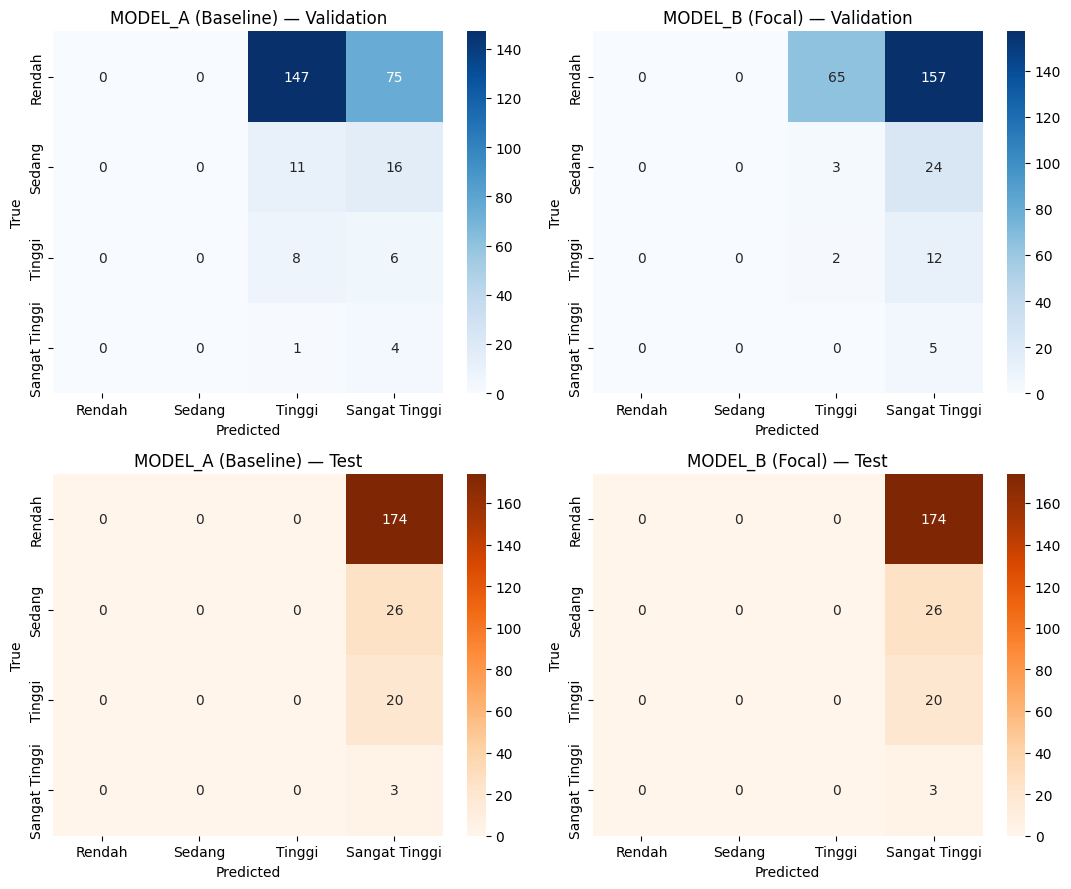

In [14]:
save_cm_csv(val_cm_baseline, os.path.join(OUTPUT_DIR, "4_class_confusion_matrix_baseline_validation.csv"))
save_cm_csv(test_cm_baseline, os.path.join(OUTPUT_DIR, "4_class_confusion_matrix_baseline_test.csv"))
save_cm_csv(val_cm_focal, os.path.join(OUTPUT_DIR, "4_class_confusion_matrix_focal_validation.csv"))
save_cm_csv(test_cm_focal, os.path.join(OUTPUT_DIR, "4_class_confusion_matrix_focal_test.csv"))

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, cm, title, cmap in [
    (axes[0, 0], val_cm_baseline, "MODEL_A (Baseline) — Validation", "Blues"),
    (axes[0, 1], val_cm_focal, "MODEL_B (Focal) — Validation", "Blues"),
    (axes[1, 0], test_cm_baseline, "MODEL_A (Baseline) — Test", "Oranges"),
    (axes[1, 1], test_cm_focal, "MODEL_B (Focal) — Test", "Oranges"),
]:
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(title)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "4_class_confusion_matrices_12a.png"), dpi=150)
plt.show()

## 11. Pemilihan Loss Terbaik (Tahap 12A)

Urutan prioritas: **Validation F1 Macro → Validation Recall Macro → Validation CSI → Validation POD → Validation Accuracy**.


In [15]:
loss_comparison_rows = [
    {"model": "MODEL_A_baseline", "loss_type": "SparseCategoricalCrossentropy",
     **{f"val_{k}": v for k, v in val_metrics_baseline.items()},
     **{f"test_{k}": v for k, v in test_metrics_baseline.items()}},
    {"model": "MODEL_B_focal", "loss_type": "WeightedFocalLoss",
     **{f"val_{k}": v for k, v in val_metrics_focal.items()},
     **{f"test_{k}": v for k, v in test_metrics_focal.items()}},
]
loss_comparison_df = pd.DataFrame(loss_comparison_rows)

priority_cols_12a = ["val_F1_Macro", "val_Recall_Macro", "val_CSI_macro", "val_POD_macro", "val_Accuracy"]
loss_ranking_df = loss_comparison_df.sort_values(by=priority_cols_12a, ascending=False).reset_index(drop=True)
loss_ranking_df.insert(0, "rank", range(1, len(loss_ranking_df) + 1))

best_loss_model = loss_ranking_df.loc[0, "model"]
best_loss_type = loss_ranking_df.loc[0, "loss_type"]

print(loss_ranking_df[["rank", "model", "loss_type"] + priority_cols_12a].to_string(index=False))
print()
print(f"Loss terbaik (dipakai untuk Tahap 12B): {best_loss_type} ({best_loss_model})")

 rank            model                     loss_type  val_F1_Macro  val_Recall_Macro  val_CSI_macro  val_POD_macro  val_Accuracy
    1 MODEL_A_baseline SparseCategoricalCrossentropy      0.040967          0.342857       0.021365       0.342857      0.044776
    2    MODEL_B_focal             WeightedFocalLoss      0.024220          0.285714       0.012411       0.285714      0.026119

Loss terbaik (dipakai untuk Tahap 12B): SparseCategoricalCrossentropy (MODEL_A_baseline)


In [31]:
print("X_train shape:", X_train.shape)
print("\nDistribusi kelas:")
print(pd.Series(y_train).value_counts().sort_index())

X_train shape: (5140, 30, 8)

Distribusi kelas:
0    1285
1    1285
2    1285
3    1285
Name: count, dtype: int64


## 14. Training Model Akhir (Tuned) dengan Parameter Warisan

Dilatih penuh dengan `epochs=100` (EarlyStopping tetap aktif) menggunakan hyperparameter terbaik dari Optuna.

In [32]:
# ============================================================
# PARAMETER WARISAN
# ============================================================

best_params = {
    "units1": 90,
    "units2": 60,
    "dropout": 0.21940347909220265,
    "learning_rate": 0.006038497979380994,
    "batch_size": 16,
    "loss_type": best_loss_type,
    "val_F1_Macro": 0.23878885323334959
}

print("=" * 70)
print("MENGGUNAKAN PARAMETER WARISAN")
print("=" * 70)
print(best_params)

MENGGUNAKAN PARAMETER WARISAN
{'units1': 90, 'units2': 60, 'dropout': 0.21940347909220265, 'learning_rate': 0.006038497979380994, 'batch_size': 16, 'loss_type': 'SparseCategoricalCrossentropy', 'val_F1_Macro': 0.23878885323334959}


In [18]:
# ============================================================
# FINAL TRAINING
#
# Konfigurasi:
# - 4 kelas
# - LB30
# - ROS = ON
# - class_weight = OFF
# - Loss = Weight Focal Loss (Alpha=None)
# - Hyperparameter = PARAMETER WARISAN
# - Epoch maksimum = 100
# - Callback = get_callbacks()
#
# Tujuan:
# Membandingkan parameter warisan dengan hasil Optuna 3 kelas
# secara adil dengan konfigurasi eksperimen yang sama.
# ============================================================


# ============================================================
# 1. VALIDASI PARAMETER WARISAN
# ============================================================

required_params = [
    "units1",
    "units2",
    "dropout",
    "learning_rate",
    "batch_size",
]

for param in required_params:
    assert param in best_params, (
        f"Parameter '{param}' tidak ditemukan dalam best_params."
    )


print("=" * 70)
print("4 KELAS")
print("=" * 70)

print("Units 1          :", best_params["units1"])
print("Units 2          :", best_params["units2"])
print("Dropout          :", best_params["dropout"])
print("Learning Rate    :", best_params["learning_rate"])
print("Batch Size       :", best_params["batch_size"])
print("Loss             : WeightFocusLoss")
print("Classes          : 3")
print("Lookback         : 30")
print("ROS              : ON")
print("Class Weight     : OFF")

if "val_F1_Macro" in best_params:
    print(
        "Historical Val F1:",
        best_params["val_F1_Macro"]
    )


# ============================================================
# 2. VALIDASI DATA
# ============================================================

print("\nData training:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nData validation:")
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("\nDistribusi y_train:")

print(
    pd.Series(y_train)
    .value_counts()
    .sort_index()
)


# ============================================================
# 3. RESET SESSION + LOCK SEED
# ============================================================

tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(SEED)


# ============================================================
# 4. BUILD MODEL
#
# Hyperparameter menggunakan parameter warisan.
# Konfigurasi eksperimen disamakan dengan Optuna 3 kelas.
# ============================================================

model_legacy = build_model(
    input_shape,

    units1=best_params["units1"],

    units2=best_params["units2"],

    dropout=best_params["dropout"],

    learning_rate=best_params["learning_rate"],

    loss = sparse_categorical_focal_loss(
    gamma=2.0,
    alpha=None),
    )


model_legacy.summary()


# ============================================================
# 5. TRAINING
#
# PENTING:
# - X_train / y_train sudah ROS
# - Validation tanpa ROS
# - class_weight OFF
# ============================================================

history_legacy = model_legacy.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=100,

    batch_size=best_params["batch_size"],

    # class_weight=class_weight_dict,

    # class_weight sengaja TIDAK digunakan

    callbacks=get_callbacks(),

    verbose=1,
)


# ============================================================
# 6. SIMPAN TRAINING HISTORY
# ============================================================

history_legacy_df = pd.DataFrame(
    history_legacy.history
)

history_legacy_df.insert(
    0,
    "epoch",
    range(
        1,
        len(history_legacy_df) + 1
    )
)


history_path = os.path.join(
    OUTPUT_DIR,
    "4_class_training_history_ROS_WeightFocusLoss_Alpha_None.csv"
)

history_legacy_df.to_csv(
    history_path,
    index=False
)


# ============================================================
# 7. SIMPAN MODEL
# ============================================================

model_path = os.path.join(
    OUTPUT_DIR,
    "4_class_model_ROS_WeightFocusLoss_Alpha_None.keras"
)

model_legacy.save(
    model_path
)


# ============================================================
# 8. RINGKASAN
# ============================================================

print("\n" + "=" * 70)
print("TRAINING 4 KELAS SELESAI")
print("=" * 70)

print(
    "Epoch aktual:",
    len(history_legacy_df)
)

if "val_loss" in history_legacy_df.columns:
    print(
        "Best Validation Loss:",
        history_legacy_df["val_loss"].min()
    )

print("\nArtefak:")

print(
    f"- Training history: {history_path}"
)

print(
    f"- Model: {model_path}"
)


history_legacy_df.tail()

4 KELAS
Units 1          : 90
Units 2          : 60
Dropout          : 0.21940347909220265
Learning Rate    : 0.006038497979380994
Batch Size       : 16
Loss             : WeightFocusLoss
Classes          : 3
Lookback         : 30
ROS              : ON
Class Weight     : OFF
Historical Val F1: 0.23878885323334959

Data training:
X_train shape: (5140, 30, 8)
y_train shape: (5140,)

Data validation:
X_val shape: (268, 30, 8)
y_val shape: (268,)

Distribusi y_train:
0    1285
1    1285
2    1285
3    1285
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 90)         │        35,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 90)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60)             │        36,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           244 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,124 (281.73 KB)

 Trainable params: 72,124 (281.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.2893 - loss: 0.7737 - val_accuracy: 0.0560 - val_loss: 0.8585 - learning_rate: 0.0060
Epoch 2/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3737 - loss: 0.6972 - val_accuracy: 0.3619 - val_loss: 0.7120 - learning_rate: 0.0060
Epoch 3/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4924 - loss: 0.5492 - val_accuracy: 0.3358 - val_loss: 0.6923 - learning_rate: 0.0060
Epoch 4/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5554 - loss: 0.4509 - val_accuracy: 0.2649 - val_loss: 0.7089 - learning_rate: 0.0060
Epoch 5/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6387 - loss: 0.3416 - val_accuracy: 0.4366 - val_loss: 0.6564 - learning_rate: 0.0060
Epoch 6/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6704 - loss: 0.3095 - val_accuracy: 0.5224 - val_loss: 0.5988 - learning_rate: 0.0060
Epoch 7/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7230 - loss: 

,epoch,accuracy,loss,val_accuracy,val_loss,learning_rate
11,12,0.856420,0.106448,0.652985,0.645038,0.003019
12,13,0.879572,0.088092,0.608209,0.644331,0.003019
13,14,0.894358,0.074237,0.589552,0.718236,0.003019
14,15,0.894747,0.073354,0.652985,0.666704,0.003019
15,16,0.902918,0.066756,0.645522,0.765348,0.003019


## 15. Evaluasi Model Tuned (Validation & Test) + Confusion Matrix Final

MODEL LEGACY — VALIDATION
{'Accuracy': 0.5223880597014925, 'Precision_Macro': 0.2563322094572094, 'Recall_Macro': 0.23945373945373943, 'F1_Macro': 0.23289955518101177, 'POD_macro': 0.23945373945373943, 'FAR_macro': 0.7436677905427905, 'CSI_macro': 0.16594084412799984}

MODEL LEGACY — TEST
{'Accuracy': 0.452914798206278, 'Precision_Macro': 0.25509116741652854, 'Recall_Macro': 0.275972590627763, 'F1_Macro': 0.2275036769621607, 'POD_macro': 0.275972590627763, 'FAR_macro': 0.7449088325834715, 'CSI_macro': 0.15415534420289856}


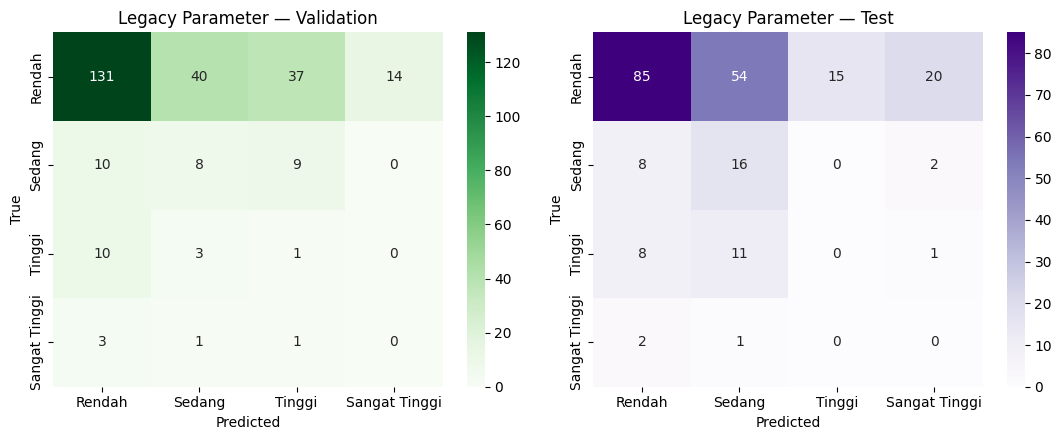


Artefak tersimpan:
- Validation CM : ./confusion_matrix_validation_model_ROS_WeightFocusLoss_Alpha_None.csv
- Test CM       : ./confusion_matrix_test_model_ROS_WeightFocusLoss_Alpha_None.csv
- Plot CM       : ./confusion_matrix_model_ROS_WeightFocusLoss_Alpha_None.png


In [19]:
# ============================================================
# STAGE 12B — LEGACY PARAMETER 3 KELAS
# EVALUASI MODEL
# ============================================================

# ------------------------------------------------------------
# 1. Pastikan model legacy tersedia
# ------------------------------------------------------------

assert "model_legacy" in globals(), (
    "model_legacy belum tersedia. "
    "Jalankan cell FINAL TRAINING Legacy Parameter terlebih dahulu."
)

# ------------------------------------------------------------
# 2. Evaluasi Validation
# ------------------------------------------------------------

val_metrics_legacy, val_cm_legacy, _ = evaluate_split(
    model_legacy,
    X_val,
    y_val
)

# ------------------------------------------------------------
# 3. Evaluasi Test
# ------------------------------------------------------------

test_metrics_legacy, test_cm_legacy, _ = evaluate_split(
    model_legacy,
    X_test,
    y_test
)

# ------------------------------------------------------------
# 4. Tampilkan hasil
# ------------------------------------------------------------

print("=" * 70)
print("MODEL LEGACY — VALIDATION")
print("=" * 70)

print(val_metrics_legacy)

print("\n" + "=" * 70)
print("MODEL LEGACY — TEST")
print("=" * 70)

print(test_metrics_legacy)

# ------------------------------------------------------------
# 5. Simpan confusion matrix CSV
# ------------------------------------------------------------

val_cm_path = os.path.join(
    OUTPUT_DIR,
    "confusion_matrix_validation_model_ROS_WeightFocusLoss_Alpha_None.csv"
)

test_cm_path = os.path.join(
    OUTPUT_DIR,
    "confusion_matrix_test_model_ROS_WeightFocusLoss_Alpha_None.csv"
)

save_cm_csv(
    val_cm_legacy,
    val_cm_path
)

save_cm_csv(
    test_cm_legacy,
    test_cm_path
)

# ------------------------------------------------------------
# 6. Visualisasi confusion matrix
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5)
)

# Validation

sns.heatmap(
    val_cm_legacy,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[0],
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

axes[0].set_title(
    "Legacy Parameter — Validation"
)

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")


# Test

sns.heatmap(
    test_cm_legacy,
    annot=True,
    fmt="d",
    cmap="Purples",
    ax=axes[1],
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

axes[1].set_title(
    "Legacy Parameter — Test"
)

axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")


plt.tight_layout()

# ------------------------------------------------------------
# 7. Simpan plot
# ------------------------------------------------------------

cm_plot_path = os.path.join(
    OUTPUT_DIR,
    "confusion_matrix_model_ROS_WeightFocusLoss_Alpha_None.png"
)

plt.savefig(
    cm_plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 8. Ringkasan
# ------------------------------------------------------------

print("\nArtefak tersimpan:")
print(f"- Validation CM : {val_cm_path}")
print(f"- Test CM       : {test_cm_path}")
print(f"- Plot CM       : {cm_plot_path}")

In [33]:
# ============================================================
# REPRODUCIBILITY TEST — 5 RUN DENGAN SEED BERBEDA
# Diletakkan setelah cell "STAGE 12B — FINAL TRAINING" (model_legacy)
# dan setelah cell evaluasi (val_metrics_legacy / test_metrics_legacy).
#
# CATATAN VERIFIKASI (harap dicek manual sebelum run):
# 1. n_classes: build_model() pada training final TIDAK meng-override
#    n_classes, sehingga memakai default global N_CLASSES = 4.
#    Komentar di cell training final menulis "3 kelas" — kemungkinan
#    komentar warisan yang tidak diperbarui. Script ini mengikuti
#    KODE AKTUAL (4 kelas), bukan komentar. Sesuaikan jika keliru.
# 2. loss: training final memanggil
#    sparse_categorical_focal_loss(gamma=2.0, alpha=None), BUKAN
#    SparseCategoricalCrossentropy seperti tertulis di komentar
#    header cell tersebut. Script ini mengikuti KODE AKTUAL.
# 3. ROS: X_train/y_train yang dipakai di sini adalah versi yang
#    SUDAH di-oversample (ROS dijalankan sekali di awal notebook
#    dengan random_state=SEED tetap, lalu variabel global ditimpa).
#    ROS TIDAK di-generate ulang per seed karena training final asli
#    juga tidak melakukannya — kelima run memakai X_train/y_train
#    hasil ROS yang identik. Jika Anda ingin ROS ikut bervariasi per
#    seed, beri tahu saya agar logika ROS dipindah ke dalam loop.
# ============================================================

SEEDS = [42, 123, 456, 789, 2025]

repro_rows = []

for seed in SEEDS:
    print("=" * 70)
    print(f"REPRODUCIBILITY RUN — seed={seed}")
    print("=" * 70)

    # 1. Reset session + set seed
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    # 2. Bangun model baru dengan konfigurasi IDENTIK dengan model_legacy
    model_repro = build_model(
        input_shape,
        units1=best_params["units1"],
        units2=best_params["units2"],
        dropout=best_params["dropout"],
        learning_rate=best_params["learning_rate"],
        loss=sparse_categorical_focal_loss(gamma=2.0, alpha=None),
        # n_classes tidak di-override -> memakai default N_CLASSES (lihat catatan #1 di atas)
    )

    # 3. Training — data split dan class_weight status IDENTIK dengan training asli
    history_repro = model_repro.fit(
        X_train, y_train,                     # X_train/y_train = versi hasil ROS (tetap, lihat catatan #3)
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=best_params["batch_size"],
        # class_weight TIDAK dikirim -> status OFF, identik dengan training asli
        callbacks=get_callbacks(),
        verbose=0,
    )

    actual_epochs = len(history_repro.history["loss"])

    # 4. Evaluasi validation & test menggunakan fungsi evaluate_split() yang sudah ada
    val_metrics_repro, _, _ = evaluate_split(model_repro, X_val, y_val)
    test_metrics_repro, _, _ = evaluate_split(model_repro, X_test, y_test)

    row = {"seed": seed, "actual_epochs": actual_epochs}
    row.update({f"val_{k}": v for k, v in val_metrics_repro.items()})
    row.update({f"test_{k}": v for k, v in test_metrics_repro.items()})
    repro_rows.append(row)

    print(f"Actual epochs : {actual_epochs}")
    print(f"Validation    : {val_metrics_repro}")
    print(f"Test          : {test_metrics_repro}")
    print()

# ============================================================
# RINGKASAN HASIL 5 RUN
# ============================================================

repro_results = pd.DataFrame(repro_rows)
print("=" * 70)
print("HASIL LENGKAP 5 RUN (REPRODUCIBILITY TEST)")
print("=" * 70)
print(repro_results.to_string(index=False))

metric_cols = [c for c in repro_results.columns if c not in ("seed", "actual_epochs")]

summary_rows = []
for col in metric_cols:
    summary_rows.append({
        "metric": col,
        "mean": repro_results[col].mean(),
        "std": repro_results[col].std(),
        "min": repro_results[col].min(),
        "max": repro_results[col].max(),
    })
repro_summary = pd.DataFrame(summary_rows)

print()
print("=" * 70)
print("RINGKASAN STATISTIK (Validation & Test) — 5 RUN")
print("=" * 70)
print(repro_summary.to_string(index=False))

# ============================================================
# SIMPAN ARTEFAK (memakai OUTPUT_DIR yang sudah ada di notebook)
# ============================================================

repro_runs_path = os.path.join(OUTPUT_DIR, "reproducibility_runs.csv")
repro_summary_path = os.path.join(OUTPUT_DIR, "reproducibility_summary.csv")

repro_results.to_csv(repro_runs_path, index=False)
repro_summary.to_csv(repro_summary_path, index=False)

print()
print(f"Tersimpan: {repro_runs_path}")
print(f"Tersimpan: {repro_summary_path}")

REPRODUCIBILITY RUN — seed=42


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Actual epochs : 21
Validation    : {'Accuracy': 0.5447761194029851, 'Precision_Macro': 0.2629016553067186, 'Recall_Macro': 0.2792077792077792, 'F1_Macro': 0.2484856007944389, 'POD_macro': 0.2792077792077792, 'FAR_macro': 0.7370983446932814, 'CSI_macro': 0.17537842319212665}
Test          : {'Accuracy': 0.6367713004484304, 'Precision_Macro': 0.26448548106516795, 'Recall_Macro': 0.29398762157382846, 'F1_Macro': 0.2720391624501214, 'POD_macro': 0.29398762157382846, 'FAR_macro': 0.735514518934832, 'CSI_macro': 0.20648355158096454}

REPRODUCIBILITY RUN — seed=123


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Actual epochs : 17
Validation    : {'Accuracy': 0.4925373134328358, 'Precision_Macro': 0.24945709466582333, 'Recall_Macro': 0.23044473044473043, 'F1_Macro': 0.2261345029239766, 'POD_macro': 0.23044473044473043, 'FAR_macro': 0.7505429053341767, 'CSI_macro': 0.15660714285714286}
Test          : {'Accuracy': 0.5739910313901345, 'Precision_Macro': 0.27849002849002846, 'Recall_Macro': 0.3094717064544651, 'F1_Macro': 0.27091607825831127, 'POD_macro': 0.3094717064544651, 'FAR_macro': 0.7215099715099715, 'CSI_macro': 0.1946280798904928}

REPRODUCIBILITY RUN — seed=456


...

Actual epochs : 20
Validation    : {'Accuracy': 0.6007462686567164, 'Precision_Macro': 0.23887122416534182, 'Recall_Macro': 0.2301051051051051, 'F1_Macro': 0.22887922887922887, 'POD_macro': 0.2301051051051051, 'FAR_macro': 0.7611287758346582, 'CSI_macro': 0.17460317460317462}
Test          : {'Accuracy': 0.5829596412556054, 'Precision_Macro': 0.2751166087433693, 'Recall_Macro': 0.2906940760389036, 'F1_Macro': 0.271493994325115, 'POD_macro': 0.2906940760389036, 'FAR_macro': 0.7248833912566307, 'CSI_macro': 0.19621212121212123}

REPRODUCIBILITY RUN — seed=789


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Actual epochs : 19
Validation    : {'Accuracy': 0.5485074626865671, 'Precision_Macro': 0.24419191919191918, 'Recall_Macro': 0.2229372229372229, 'F1_Macro': 0.22311265137437783, 'POD_macro': 0.2229372229372229, 'FAR_macro': 0.7558080808080808, 'CSI_macro': 0.16496413886552658}
Test          : {'Accuracy': 0.5695067264573991, 'Precision_Macro': 0.2738708770614693, 'Recall_Macro': 0.29167771883289123, 'F1_Macro': 0.268009768009768, 'POD_macro': 0.29167771883289123, 'FAR_macro': 0.7261291229385307, 'CSI_macro': 0.19274891774891775}

REPRODUCIBILITY RUN — seed=2025


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Actual epochs : 25
Validation    : {'Accuracy': 0.6194029850746269, 'Precision_Macro': 0.22397435897435897, 'Recall_Macro': 0.21133633633633636, 'F1_Macro': 0.21492416456445235, 'POD_macro': 0.21133633633633636, 'FAR_macro': 0.776025641025641, 'CSI_macro': 0.17056820600127687}
Test          : {'Accuracy': 0.5515695067264574, 'Precision_Macro': 0.25625, 'Recall_Macro': 0.23974358974358972, 'F1_Macro': 0.24249069643806487, 'POD_macro': 0.23974358974358972, 'FAR_macro': 0.74375, 'CSI_macro': 0.17516865901290093}

HASIL LENGKAP 5 RUN (REPRODUCIBILITY TEST)
 seed  actual_epochs  val_Accuracy  val_Precision_Macro  val_Recall_Macro  val_F1_Macro  val_POD_macro  val_FAR_macro  val_CSI_macro  test_Accuracy  test_Precision_Macro  test_Recall_Macro  test_F1_Macro  test_POD_macro  test_FAR_macro  test_CSI_macro
   42             21      0.544776             0.262902          0.279208      0.248486       0.279208       0.737098       0.175378       0.636771              0.264485           0.293988 

## 16. Tabel Perbandingan Akhir: Baseline vs Focal vs Tuned

In [20]:
# ============================================================
# PERBANDINGAN MODEL
# ============================================================

comparison_rows = [

    # --------------------------------------------------------
    # 1. Baseline
    # --------------------------------------------------------
    {
        "model": "baseline",
        "loss_type": "SparseCategoricalCrossentropy",

        **{
            f"val_{k}": v
            for k, v in val_metrics_baseline.items()
        },

        **{
            f"test_{k}": v
            for k, v in test_metrics_baseline.items()
        },
    },


    # --------------------------------------------------------
    # 2. Focal Loss
    # --------------------------------------------------------
    {
        "model": "focal",
        "loss_type": "WeightedFocalLoss",

        **{
            f"val_{k}": v
            for k, v in val_metrics_focal.items()
        },

        **{
            f"test_{k}": v
            for k, v in test_metrics_focal.items()
        },
    },


    # --------------------------------------------------------
    # 3. Legacy Parameter
    #
    # Parameter lama diuji ulang dengan konfigurasi:
    # - 3 kelas
    # - LB30
    # - ROS ON
    # - class_weight OFF
    # - WeightedFocalLoss
    # --------------------------------------------------------
    {
        "model": "legacy_parameter",
        "loss_type": "WeightedFocalLoss",

        **{
            f"val_{k}": v
            for k, v in val_metrics_legacy.items()
        },

        **{
            f"test_{k}": v
            for k, v in test_metrics_legacy.items()
        },
    },

]


# ============================================================
# BUAT DATAFRAME
# ============================================================

comparison_optimization_df = pd.DataFrame(
    comparison_rows
)


# ============================================================
# SIMPAN
#
# Gunakan nama baru agar tidak menimpa hasil perbandingan lama.
# ============================================================

comparison_path = os.path.join(
    OUTPUT_DIR,
    "comparison_optimization_4_class.csv"
)

comparison_optimization_df.to_csv(
    comparison_path,
    index=False
)


# ============================================================
# TAMPILKAN
# ============================================================

print("=" * 70)
print("PERBANDINGAN MODEL — LEGACY PARAMETER 3 KELAS")
print("=" * 70)

print(comparison_optimization_df)

print("\nDisimpan ke:")
print(comparison_path)

PERBANDINGAN MODEL — LEGACY PARAMETER 3 KELAS
              model                      loss_type  val_Accuracy  \
0          baseline  SparseCategoricalCrossentropy      0.044776   
1             focal              WeightedFocalLoss      0.026119   
2  legacy_parameter              WeightedFocalLoss      0.522388   

   val_Precision_Macro  val_Recall_Macro  val_F1_Macro  val_POD_macro  \
0             0.021877          0.342857      0.040967       0.342857   
1             0.013456          0.285714      0.024220       0.285714   
2             0.256332          0.239454      0.232900       0.239454   

   val_FAR_macro  val_CSI_macro  test_Accuracy  test_Precision_Macro  \
0       0.478123       0.021365       0.013453              0.003363   
1       0.486544       0.012411       0.013453              0.003363   
2       0.743668       0.165941       0.452915              0.255091   

   test_Recall_Macro  test_F1_Macro  test_POD_macro  test_FAR_macro  \
0           0.250000       0

## 17. Ranking Model Akhir

Ranking menggunakan prioritas yang sama seperti pemilihan loss (Bagian 11), diterapkan pada Validation set, untuk konsistensi metodologi di seluruh Stage 12.

In [21]:
priority_cols_final = ["val_F1_Macro", "val_Recall_Macro", "val_CSI_macro", "val_POD_macro", "val_Accuracy"]
final_ranking_df = comparison_optimization_df.sort_values(by=priority_cols_final, ascending=False).reset_index(drop=True)
final_ranking_df.insert(0, "rank", range(1, len(final_ranking_df) + 1))

best_model_name = final_ranking_df.loc[0, "model"]

print(final_ranking_df[["rank", "model", "loss_type"] + priority_cols_final].to_string(index=False))
print()
print(f"Model terbaik Stage 12: {best_model_name}")

 rank            model                     loss_type  val_F1_Macro  val_Recall_Macro  val_CSI_macro  val_POD_macro  val_Accuracy
    1 legacy_parameter             WeightedFocalLoss      0.232900          0.239454       0.165941       0.239454      0.522388
    2         baseline SparseCategoricalCrossentropy      0.040967          0.342857       0.021365       0.342857      0.044776
    3            focal             WeightedFocalLoss      0.024220          0.285714       0.012411       0.285714      0.026119

Model terbaik Stage 12: legacy_parameter


## 18. Simpan Model & Verifikasi Seluruh Artefak

In [22]:
# ============================================================
# STAGE 12B — SIMPAN MODEL + VALIDASI ARTEFAK
#
# Model yang dibandingkan:
# 1. Baseline
# 2. Focal Loss
# 3. Optuna 3-Class
# 4. Legacy Parameter 3-Class
# ============================================================


# ============================================================
# 1. SIMPAN MODEL
# ============================================================

# Baseline
model_baseline.save(
    os.path.join(
        OUTPUT_DIR,
        "model_baseline.keras"
    )
)

# Focal
model_focal.save(
    os.path.join(
        OUTPUT_DIR,
        "model_focal.keras"
    )
)

# Optuna 3-Class
# Jalankan hanya jika model_tuned masih tersedia
if "model_tuned" in globals():
    model_tuned.save(
        os.path.join(
            OUTPUT_DIR,
            "model_tuned_final_4_class.keras"
        )
    )

# Legacy Parameter 3-Class
model_path = os.path.join(
    OUTPUT_DIR,
    "model_final_4_class.keras"
)

model_legacy.save(model_path)

# ============================================================
# 2. ARTEFAK WAJIB
# ============================================================

required_files = [

    # -------------------------
    # Model
    # -------------------------
    "model_baseline.keras",
    "model_focal.keras",
    "model_tuned_final_4_class.keras",
    "model_final_4_class.keras",

    # -------------------------
    # Comparison
    # -------------------------
    "comparison_optimization_4_class",

    # -------------------------
    # Training History
    # -------------------------
    "4_class_training_history_focal.csv",
    "4_class_training_history_baseline.csv",
    "model_tuned_final_4_class.csv",
    "model_final_4_class.keras",

]

print("=" * 70)
print("ARTEFAK WAJIB")
print("=" * 70)

for f in required_files:

    path = os.path.join(
        OUTPUT_DIR,
        f
    )

    status = (
        "OK"
        if os.path.exists(path)
        else "MISSING"
    )

    print(
        f"[{status}] {f}"
    )


# ============================================================
# 3. ARTEFAK CONFUSION MATRIX
# ============================================================

confusion_matrix_files = [

    # Baseline
    "confusion_matrix_baseline_validation.csv",
    "confusion_matrix_baseline_test.csv",

    # Focal
    "confusion_matrix_focal_validation.csv",
    "confusion_matrix_focal_test.csv",

    # Optuna 3-Class
    "confusion_matrix_validation.csv",
    "confusion_matrix_test.csv",
    "confusion_matrix_tuned.png",

    # Legacy 3-Class
    "confusion_matrix_validation_model_ROS_WeightFocusLoss_Alpha_None.csv",
    "confusion_matrix_test_model_ROS_WeightFocusLoss_Alpha_None.csv",
    "confusion_matrix_model_ROS_WeightFocusLoss_Alpha_None",

]

print("\n" + "=" * 70)
print("ARTEFAK CONFUSION MATRIX")
print("=" * 70)

for f in confusion_matrix_files:

    path = os.path.join(
        OUTPUT_DIR,
        f
    )

    status = (
        "OK"
        if os.path.exists(path)
        else "MISSING"
    )

    print(
        f"[{status}] {f}"
    )


# ============================================================
# 4. ARTEFAK PELENGKAP
# ============================================================

supplementary_files = [

    # Distribusi kelas
    "4_class_distribution_train.png",

    # Visualisasi eksperimen sebelumnya
    "4_class_confusion_matrices_12a.png",

    # Reproducibility Optuna
    "reproducibility_runs.csv",
    "reproducibility_val_f1.png",

]

print("\n" + "=" * 70)
print("ARTEFAK PELENGKAP")
print("=" * 70)

for f in supplementary_files:

    path = os.path.join(
        OUTPUT_DIR,
        f
    )

    status = (
        "OK"
        if os.path.exists(path)
        else "MISSING"
    )

    print(
        f"[{status}] {f}"
    )

ARTEFAK WAJIB
[OK] model_baseline.keras
[OK] model_focal.keras
[MISSING] model_tuned_final_4_class.keras
[OK] model_final_4_class.keras
[MISSING] comparison_optimization_4_class
[OK] 4_class_training_history_focal.csv
[OK] 4_class_training_history_baseline.csv
[MISSING] model_tuned_final_4_class.csv
[OK] model_final_4_class.keras

ARTEFAK CONFUSION MATRIX
[MISSING] confusion_matrix_baseline_validation.csv
[MISSING] confusion_matrix_baseline_test.csv
[MISSING] confusion_matrix_focal_validation.csv
[MISSING] confusion_matrix_focal_test.csv
[MISSING] confusion_matrix_validation.csv
[MISSING] confusion_matrix_test.csv
[MISSING] confusion_matrix_tuned.png
[OK] confusion_matrix_validation_model_ROS_WeightFocusLoss_Alpha_None.csv
[OK] confusion_matrix_test_model_ROS_WeightFocusLoss_Alpha_None.csv
[MISSING] confusion_matrix_model_ROS_WeightFocusLoss_Alpha_None

ARTEFAK PELENGKAP
[OK] 4_class_distribution_train.png
[OK] 4_class_confusion_matrices_12a.png
[MISSING] reproducibility_runs.csv
[MISS

## 19. Output Akhir

In [23]:
# ============================================================
# RINGKASAN HASIL SELURUH MODEL
# ============================================================

print("=" * 70)
print("HASIL BASELINE")
print("MODEL_A: SparseCategoricalCrossentropy + class_weight")
print("=" * 70)

print("Validation:", val_metrics_baseline)
print("Test:      ", test_metrics_baseline)


print()
print("=" * 70)
print("HASIL FOCAL")
print("MODEL_B: Weighted Focal Loss + class_weight")
print("=" * 70)

print("Validation:", val_metrics_focal)
print("Test:      ", test_metrics_focal)

print()
print("=" * 70)
print("HASIL PARAMETER WARISAN 4-KELAS")
print("=" * 70)

print("Legacy params:", best_params)

print(
    "Validation:",
    val_metrics_legacy
)

print(
    "Test:      ",
    test_metrics_legacy
)


print()
print("=" * 70)
print("RANKING MODEL")
print("Prioritas:")
print("Validation F1 Macro > Recall Macro > CSI > POD > Accuracy")
print("=" * 70)

print(
    final_ranking_df[
        ["rank", "model", "loss_type"]
        + priority_cols_final
    ].to_string(index=False)
)


print()
print("=" * 70)
print(
    f">>> MODEL TERBAIK STAGE 12: "
    f"{best_model_name} <<<"
)
print("=" * 70)


print()
print(
    "Seluruh artefak disimpan di:",
    os.path.abspath(OUTPUT_DIR)
)

HASIL BASELINE
MODEL_A: SparseCategoricalCrossentropy + class_weight
Validation: {'Accuracy': 0.04477611940298507, 'Precision_Macro': 0.021877038003201517, 'Recall_Macro': 0.34285714285714286, 'F1_Macro': 0.040967372042114036, 'POD_macro': 0.34285714285714286, 'FAR_macro': 0.4781229619967985, 'CSI_macro': 0.02136461521024595}
Test:       {'Accuracy': 0.013452914798206279, 'Precision_Macro': 0.0033632286995515697, 'Recall_Macro': 0.25, 'F1_Macro': 0.00663716814159292, 'POD_macro': 0.25, 'FAR_macro': 0.24663677130044842, 'CSI_macro': 0.0033632286995515697}

HASIL FOCAL
MODEL_B: Weighted Focal Loss + class_weight
Validation: {'Accuracy': 0.026119402985074626, 'Precision_Macro': 0.013455988455988456, 'Recall_Macro': 0.2857142857142857, 'F1_Macro': 0.024220032840722494, 'POD_macro': 0.2857142857142857, 'FAR_macro': 0.4865440115440115, 'CSI_macro': 0.01241069228874107}
Test:       {'Accuracy': 0.013452914798206279, 'Precision_Macro': 0.0033632286995515697, 'Recall_Macro': 0.25, 'F1_Macro': 0

## 20. Visualisasi Hasil Akhir (untuk Bab 4 Skripsi)

Section ini **hanya berisi visualisasi dan penyimpanan gambar/tabel** untuk kebutuhan penulisan Bab 4.
Tidak ada training ulang, tuning, maupun eksperimen — seluruh visualisasi menggunakan objek yang sudah
tersedia di notebook ini (`history_tuned`, `model_tuned`, `val_cm_tuned`, `test_cm_tuned`,
`val_metrics_tuned`, `test_metrics_tuned`, `X_val`, `y_val`, `X_test`, `y_test`, dll.), dengan Model Tuned
sebagai model final Stage 12.


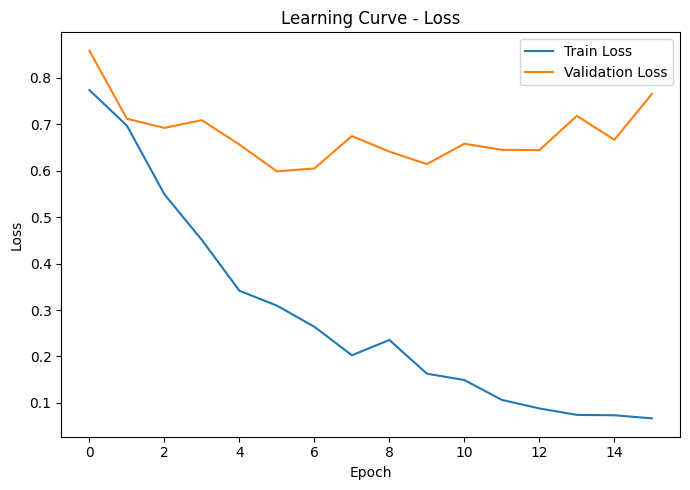

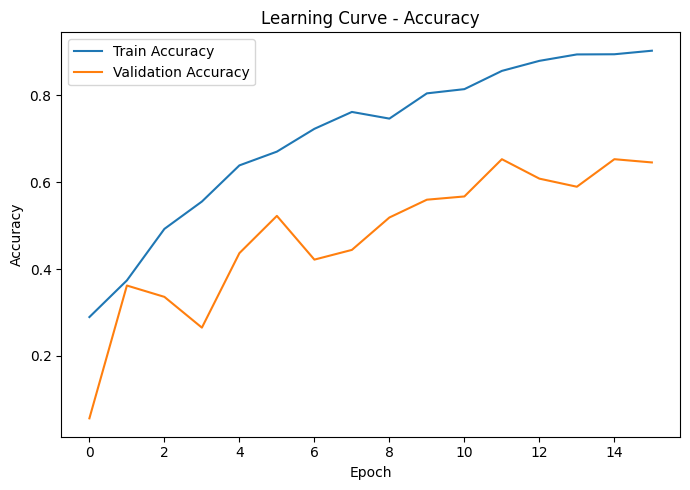

In [24]:
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize


# ============================================================
# LEARNING CURVE — LEGACY PARAMETER MODEL 4 KELAS
# ============================================================

# Ambil history dari training model legacy
hist_legacy = history_legacy.history


# ============================================================
# 1. LEARNING CURVE — LOSS
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    hist_legacy["loss"],
    label="Train Loss"
)

ax.plot(
    hist_legacy["val_loss"],
    label="Validation Loss"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

ax.set_title(
    "Learning Curve - Loss"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "learning_curve_loss.png"
    ),
    dpi=150
)

plt.show()


# ============================================================
# 2. LEARNING CURVE — ACCURACY
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    hist_legacy["accuracy"],
    label="Train Accuracy"
)

ax.plot(
    hist_legacy["val_accuracy"],
    label="Validation Accuracy"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")

ax.set_title(
    "Learning Curve - Accuracy"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "learning_curve_accuracy.png"
    ),
    dpi=150
)

plt.show()

### 20.3 ROC Curve (One-vs-Rest) - Validation & Test (Model Tuned)

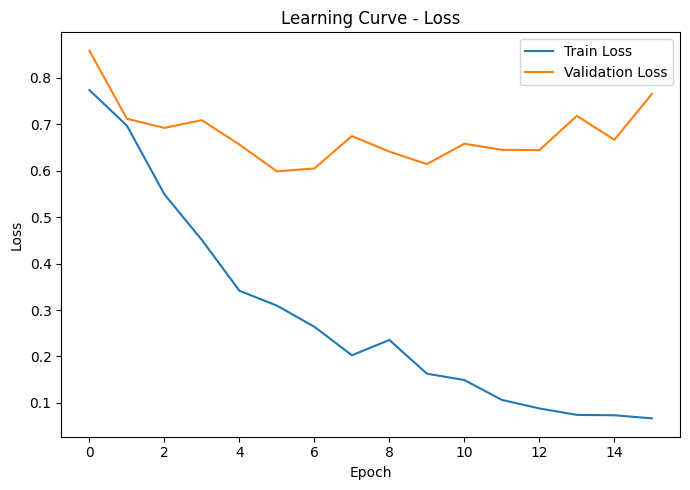

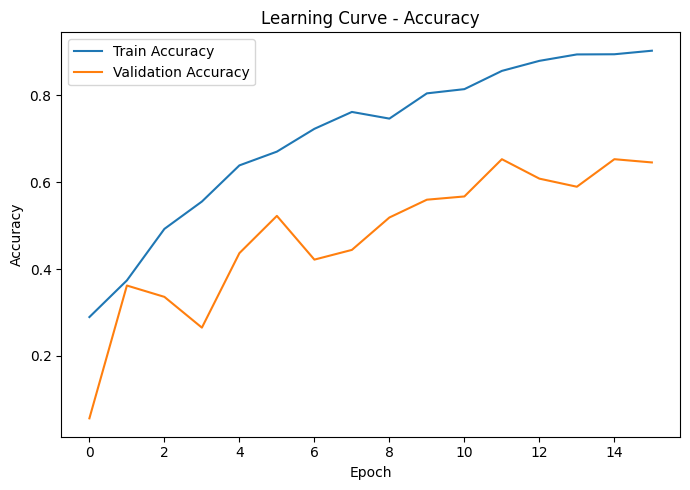

In [25]:
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

# ============================================================
# LEARNING CURVE — LEGACY PARAMETER MODEL
# ============================================================

# Ambil history hasil training model legacy
hist_legacy = history_legacy.history

# ------------------------------------------------------------
# 1. Learning Curve — Loss
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    hist_legacy["loss"],
    label="Train Loss"
)

ax.plot(
    hist_legacy["val_loss"],
    label="Validation Loss"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

ax.set_title(
    "Learning Curve - Loss"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "learning_curve_loss.png"
    ),
    dpi=150
)

plt.show()


# ------------------------------------------------------------
# 2. Learning Curve — Accuracy
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    hist_legacy["accuracy"],
    label="Train Accuracy"
)

ax.plot(
    hist_legacy["val_accuracy"],
    label="Validation Accuracy"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")

ax.set_title(
    "Learning Curve - Accuracy"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "learning_curve_accuracy.png"
    ),
    dpi=150
)

plt.show()

### 20.4 Precision-Recall Curve (One-vs-Rest) - Validation & Test (Model Tuned)

ROC & PRECISION-RECALL CURVE
LEGACY PARAMETER MODEL — 3 KELAS
Model    : model_legacy
Classes  : 4
Class names: ['Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']

Prediction probability shape:
Validation: (268, 4)
Test: (223, 4)

Binarized label shape:
Validation: (268, 4)
Test: (223, 4)


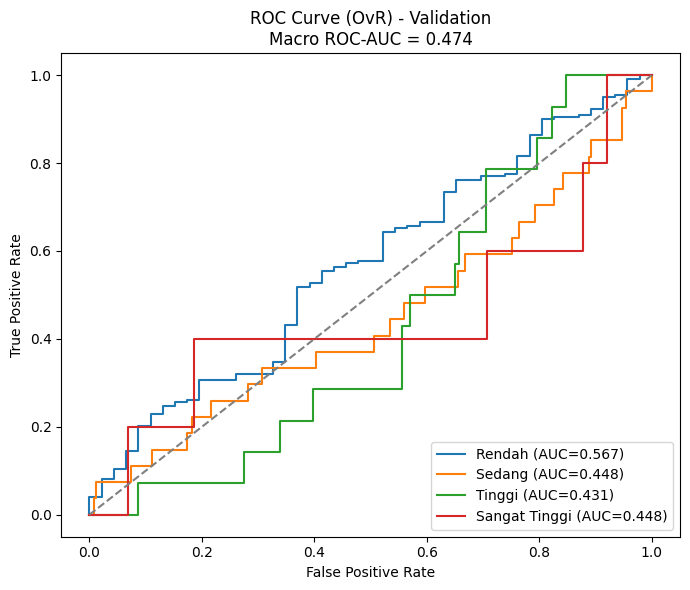

ROC curve disimpan: ./roc_validation_4class.png


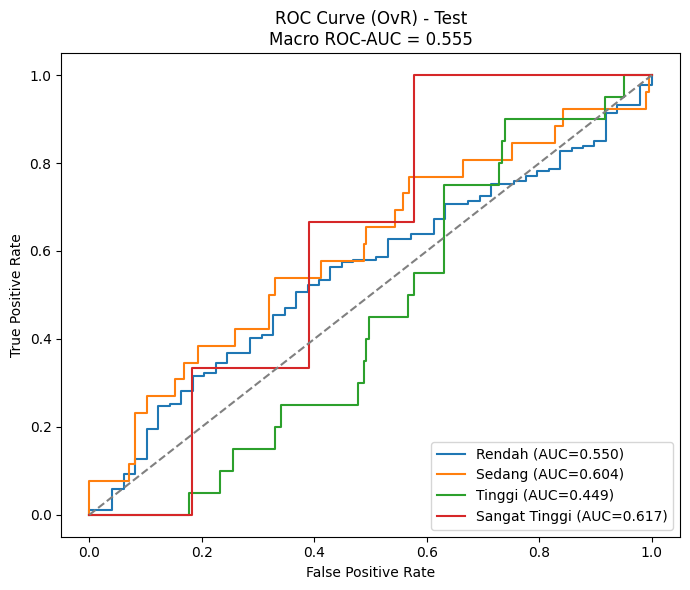

ROC curve disimpan: ./roc_test_legacy_4class.png


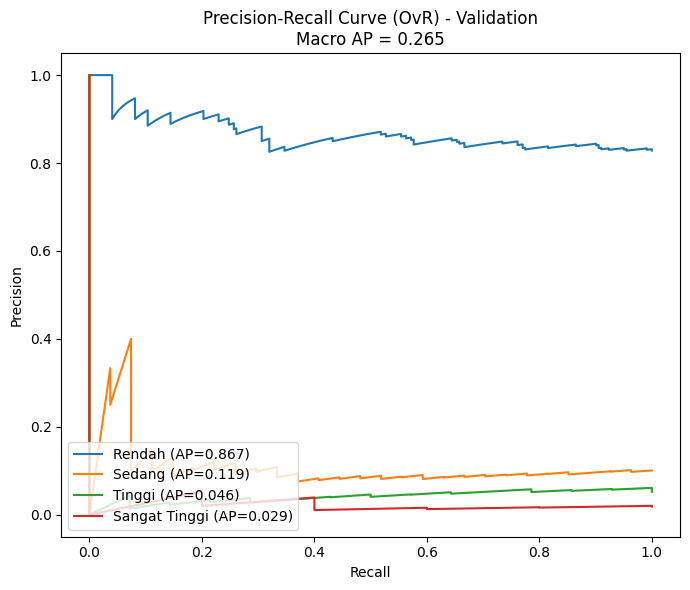

Precision-Recall curve disimpan: ./pr_curve_validation_legacy_4class.png


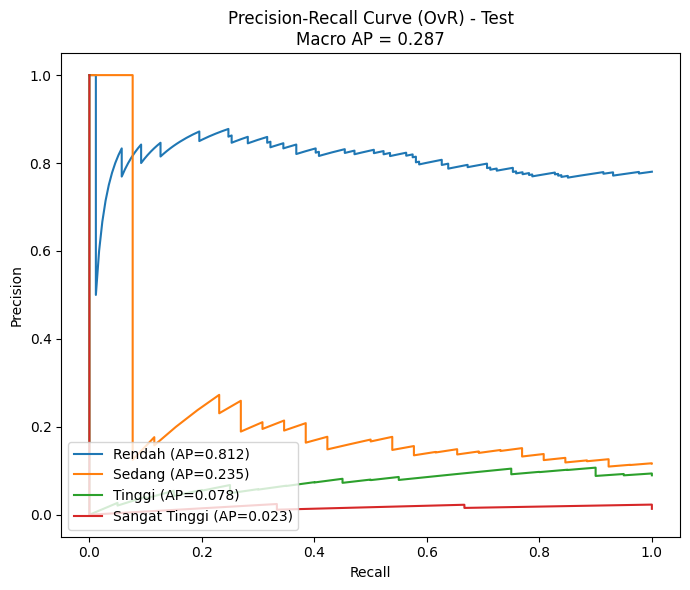

Precision-Recall curve disimpan: ./pr_curve_test_legacy_4class.png

RINGKASAN ROC & PRECISION-RECALL
LEGACY PARAMETER MODEL — 4 KELAS
Macro ROC-AUC Validation : 0.4737
Macro ROC-AUC Test       : 0.5549
Macro Average Precision Validation : 0.2654
Macro Average Precision Test       : 0.2872

Artefak:
- roc_validation_4class.png
- roc_test_4class.png
- pr_curve_validation_4class.png
- pr_curve_test_4class.png


In [26]:
# ============================================================
# STAGE 12B — LEGACY PARAMETER 4 KELAS
# ROC CURVE + PRECISION-RECALL CURVE
#
# Model:
# - 4 kelas
# - LB30
# - ROS = ON
# - class_weight = OFF
# - WeighFocalLoss
# - Hyperparameter = Legacy Parameter
# ============================================================

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.preprocessing import label_binarize


# ============================================================
# 1. VALIDASI MODEL DAN DATA
# ============================================================

assert "model_legacy" in globals(), (
    "model_legacy belum tersedia. "
    "Jalankan Final Training Legacy Parameter terlebih dahulu."
)

assert "X_val" in globals(), "X_val belum tersedia."
assert "y_val" in globals(), "y_val belum tersedia."

assert "X_test" in globals(), "X_test belum tersedia."
assert "y_test" in globals(), "y_test belum tersedia."

assert "N_CLASSES" in globals(), (
    "N_CLASSES belum tersedia."
)

assert "CLASS_NAMES" in globals(), (
    "CLASS_NAMES belum tersedia."
)

print("=" * 70)
print("ROC & PRECISION-RECALL CURVE")
print("LEGACY PARAMETER MODEL — 3 KELAS")
print("=" * 70)

print("Model    : model_legacy")
print("Classes  :", N_CLASSES)
print("Class names:", CLASS_NAMES)


# ============================================================
# 2. HITUNG PROBABILITAS PREDIKSI
#
# Tidak melakukan training ulang.
# Hanya inferensi menggunakan model_legacy yang sudah dilatih.
# ============================================================

y_val_proba = model_legacy.predict(
    X_val,
    verbose=0
)

y_test_proba = model_legacy.predict(
    X_test,
    verbose=0
)


print("\nPrediction probability shape:")

print(
    "Validation:",
    y_val_proba.shape
)

print(
    "Test:",
    y_test_proba.shape
)


# ============================================================
# 3. BINARISASI LABEL
#
# Wajib untuk ROC dan Precision-Recall multiclass
# dengan pendekatan One-vs-Rest.
# ============================================================

classes = list(
    range(N_CLASSES)
)

y_val_bin = label_binarize(
    y_val,
    classes=classes
)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)


print("\nBinarized label shape:")

print(
    "Validation:",
    y_val_bin.shape
)

print(
    "Test:",
    y_test_bin.shape
)


# ============================================================
# 4. FUNGSI ROC CURVE ONE-vs-REST
# ============================================================

def plot_roc_ovr(
    y_bin,
    y_proba,
    title,
    filename
):

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    aucs = []

    for c in range(N_CLASSES):

        fpr, tpr, _ = roc_curve(
            y_bin[:, c],
            y_proba[:, c]
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        aucs.append(
            roc_auc
        )

        ax.plot(
            fpr,
            tpr,
            label=(
                f"{CLASS_NAMES[c]} "
                f"(AUC={roc_auc:.3f})"
            )
        )

    macro_auc = float(
        np.mean(aucs)
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray"
    )

    ax.set_xlabel(
        "False Positive Rate"
    )

    ax.set_ylabel(
        "True Positive Rate"
    )

    ax.set_title(
        f"{title}\n"
        f"Macro ROC-AUC = {macro_auc:.3f}"
    )

    ax.legend(
        loc="lower right"
    )

    plt.tight_layout()

    output_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    plt.savefig(
        output_path,
        dpi=150
    )

    plt.show()

    print(
        f"ROC curve disimpan: {output_path}"
    )

    return macro_auc


# ============================================================
# 5. ROC CURVE VALIDATION
# ============================================================

roc_auc_macro_val = plot_roc_ovr(
    y_val_bin,
    y_val_proba,
    "ROC Curve (OvR) - Validation",
    "roc_validation_4class.png"
)


# ============================================================
# 6. ROC CURVE TEST
# ============================================================

roc_auc_macro_test = plot_roc_ovr(
    y_test_bin,
    y_test_proba,
    "ROC Curve (OvR) - Test",
    "roc_test_legacy_4class.png"
)


# ============================================================
# 7. FUNGSI PRECISION-RECALL CURVE ONE-vs-REST
# ============================================================

def plot_pr_ovr(
    y_bin,
    y_proba,
    title,
    filename
):

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    aps = []

    for c in range(N_CLASSES):

        precision, recall, _ = precision_recall_curve(
            y_bin[:, c],
            y_proba[:, c]
        )

        ap = average_precision_score(
            y_bin[:, c],
            y_proba[:, c]
        )

        aps.append(
            ap
        )

        ax.plot(
            recall,
            precision,
            label=(
                f"{CLASS_NAMES[c]} "
                f"(AP={ap:.3f})"
            )
        )

    macro_ap = float(
        np.mean(aps)
    )

    ax.set_xlabel(
        "Recall"
    )

    ax.set_ylabel(
        "Precision"
    )

    ax.set_title(
        f"{title}\n"
        f"Macro AP = {macro_ap:.3f}"
    )

    ax.legend(
        loc="lower left"
    )

    plt.tight_layout()

    output_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    plt.savefig(
        output_path,
        dpi=150
    )

    plt.show()

    print(
        f"Precision-Recall curve disimpan: {output_path}"
    )

    return macro_ap


# ============================================================
# 8. PRECISION-RECALL CURVE VALIDATION
# ============================================================

pr_ap_macro_val = plot_pr_ovr(
    y_val_bin,
    y_val_proba,
    "Precision-Recall Curve (OvR) - Validation",
    "pr_curve_validation_legacy_4class.png"
)


# ============================================================
# 9. PRECISION-RECALL CURVE TEST
# ============================================================

pr_ap_macro_test = plot_pr_ovr(
    y_test_bin,
    y_test_proba,
    "Precision-Recall Curve (OvR) - Test",
    "pr_curve_test_legacy_4class.png"
)


# ============================================================
# 10. RINGKASAN
# ============================================================

print("\n" + "=" * 70)
print("RINGKASAN ROC & PRECISION-RECALL")
print("LEGACY PARAMETER MODEL — 4 KELAS")
print("=" * 70)

print(
    f"Macro ROC-AUC Validation : "
    f"{roc_auc_macro_val:.4f}"
)

print(
    f"Macro ROC-AUC Test       : "
    f"{roc_auc_macro_test:.4f}"
)

print(
    f"Macro Average Precision Validation : "
    f"{pr_ap_macro_val:.4f}"
)

print(
    f"Macro Average Precision Test       : "
    f"{pr_ap_macro_test:.4f}"
)

print("\nArtefak:")
print(
    "- roc_validation_4class.png"
)
print(
    "- roc_test_4class.png"
)
print(
    "- pr_curve_validation_4class.png"
)
print(
    "- pr_curve_test_4class.png"
)

### 20.5 POD, FAR, CSI per Kelas - Validation & Test (Model Tuned)

In [27]:
# ============================================================
# POD, FAR, CSI PER KELAS — LEGACY PARAMETER MODEL
#
# One-vs-Rest
#
# Dihitung dari confusion matrix:
# - val_cm_legacy
# - test_cm_legacy
# ============================================================


# ============================================================
# 1. VALIDASI CONFUSION MATRIX
# ============================================================

assert "val_cm_legacy" in globals(), (
    "val_cm_legacy belum tersedia. "
    "Jalankan evaluasi Legacy Parameter Model terlebih dahulu."
)

assert "test_cm_legacy" in globals(), (
    "test_cm_legacy belum tersedia. "
    "Jalankan evaluasi Legacy Parameter Model terlebih dahulu."
)

assert "CLASS_NAMES" in globals(), (
    "CLASS_NAMES belum tersedia."
)


# ============================================================
# 2. FUNGSI POD, FAR, CSI PER KELAS
#
# Pendekatan One-vs-Rest
# ============================================================

def pod_far_csi_per_class(cm, class_names=CLASS_NAMES):

    rows = []

    for c in range(len(class_names)):

        # True Positive
        TP = cm[c, c]

        # False Negative
        FN = cm[c, :].sum() - TP

        # False Positive
        FP = cm[:, c].sum() - TP

        # Probability of Detection / Recall
        pod = (
            TP / (TP + FN)
            if (TP + FN) > 0
            else 0.0
        )

        # False Alarm Ratio
        far = (
            FP / (TP + FP)
            if (TP + FP) > 0
            else 0.0
        )

        # Critical Success Index
        csi = (
            TP / (TP + FP + FN)
            if (TP + FP + FN) > 0
            else 0.0
        )

        rows.append({
            "class": class_names[c],
            "POD": pod,
            "FAR": far,
            "CSI": csi
        })

    return pd.DataFrame(rows)


# ============================================================
# 3. VALIDATION
# ============================================================

pod_far_csi_val_df = pod_far_csi_per_class(
    val_cm_legacy
)

pod_far_csi_val_df.insert(
    0,
    "split",
    "validation"
)


# ============================================================
# 4. TEST
# ============================================================

pod_far_csi_test_df = pod_far_csi_per_class(
    test_cm_legacy
)

pod_far_csi_test_df.insert(
    0,
    "split",
    "test"
)


# ============================================================
# 5. GABUNGKAN HASIL
# ============================================================

pod_far_csi_per_class_df = pd.concat(
    [
        pod_far_csi_val_df,
        pod_far_csi_test_df
    ],
    ignore_index=True
)


# ============================================================
# 6. SIMPAN CSV
# ============================================================

pod_far_csi_per_class_path = os.path.join(
    OUTPUT_DIR,
    "pod_far_csi_per_class_4class.csv"
)

pod_far_csi_per_class_df.to_csv(
    pod_far_csi_per_class_path,
    index=False
)


# ============================================================
# 7. TAMPILKAN HASIL
# ============================================================

print("=" * 70)
print("POD, FAR, CSI PER KELAS")
print("LEGACY PARAMETER MODEL — 3 KELAS")
print("=" * 70)

print(
    pod_far_csi_per_class_df.to_string(
        index=False
    )
)

print("\nArtefak disimpan:")
print(
    pod_far_csi_per_class_path
)

POD, FAR, CSI PER KELAS
LEGACY PARAMETER MODEL — 3 KELAS
     split         class      POD      FAR      CSI
validation        Rendah 0.590090 0.149351 0.534694
validation        Sedang 0.296296 0.846154 0.112676
validation        Tinggi 0.071429 0.979167 0.016393
validation Sangat Tinggi 0.000000 1.000000 0.000000
      test        Rendah 0.488506 0.174757 0.442708
      test        Sedang 0.615385 0.804878 0.173913
      test        Tinggi 0.000000 1.000000 0.000000
      test Sangat Tinggi 0.000000 1.000000 0.000000

Artefak disimpan:
./pod_far_csi_per_class_4class.csv


### 20.6 Grafik POD, FAR, CSI per Kelas

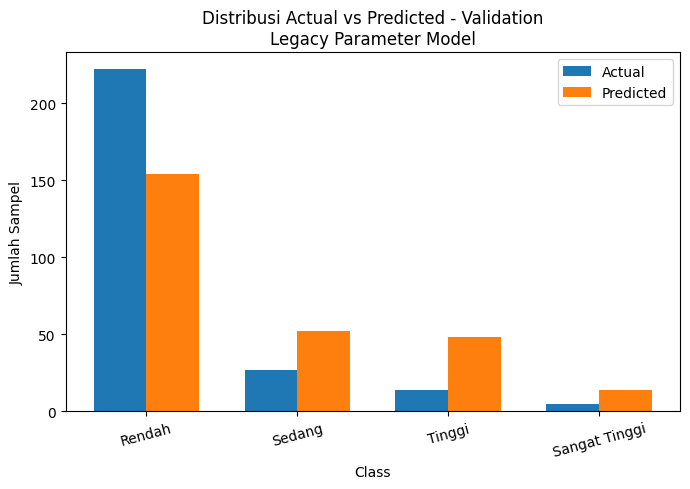

Grafik disimpan: ./prediction_distribution_validation_4class.png


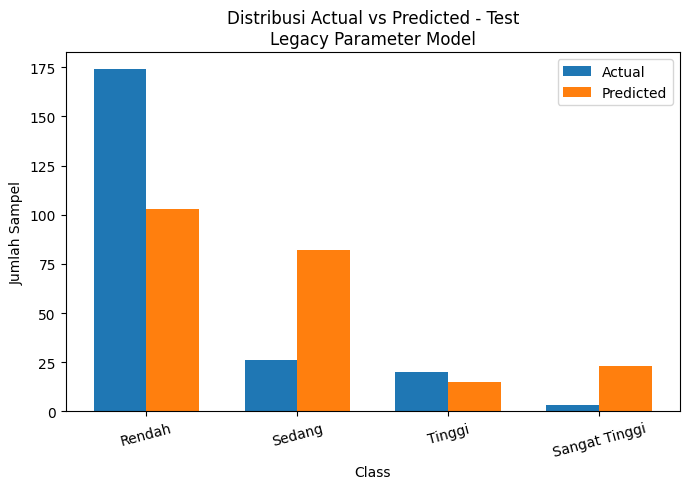

Grafik disimpan: ./prediction_distribution_test_4class.png

DISTRIBUSI ACTUAL VS PREDICTED
LEGACY PARAMETER MODEL — 3 KELAS
     split         class  actual  predicted
validation        Rendah     222        154
validation        Sedang      27         52
validation        Tinggi      14         48
validation Sangat Tinggi       5         14
      test        Rendah     174        103
      test        Sedang      26         82
      test        Tinggi      20         15
      test Sangat Tinggi       3         23

Artefak:
- prediction_distribution_validation_4class.png
- prediction_distribution_test_4class.png
- prediction_distribution_4class.csv


In [28]:
# ============================================================
# DISTRIBUSI ACTUAL VS PREDICTED
# LEGACY PARAMETER MODEL — 4 KELAS
#
# Validation & Test
#
# y_val_pred dan y_test_pred diturunkan dari probabilitas:
# - y_val_proba
# - y_test_proba
#
# Probabilitas tersebut berasal dari model_legacy.
# Tidak ada training atau inferensi ulang.
# ============================================================


# ============================================================
# 1. VALIDASI VARIABEL
# ============================================================

assert "y_val_proba" in globals(), (
    "y_val_proba belum tersedia. "
    "Jalankan cell ROC/PR Curve Legacy Parameter terlebih dahulu."
)

assert "y_test_proba" in globals(), (
    "y_test_proba belum tersedia. "
    "Jalankan cell ROC/PR Curve Legacy Parameter terlebih dahulu."
)

assert "y_val" in globals(), "y_val belum tersedia."
assert "y_test" in globals(), "y_test belum tersedia."

assert "N_CLASSES" in globals(), (
    "N_CLASSES belum tersedia."
)

assert "CLASS_NAMES" in globals(), (
    "CLASS_NAMES belum tersedia."
)


# ============================================================
# 2. UBAH PROBABILITAS MENJADI LABEL PREDIKSI
#
# Konsisten dengan evaluate_split()
# ============================================================

y_val_pred = np.argmax(
    y_val_proba,
    axis=1
)

y_test_pred = np.argmax(
    y_test_proba,
    axis=1
)


# ============================================================
# 3. FUNGSI PLOT ACTUAL VS PREDICTED
# ============================================================

def plot_actual_vs_pred(
    y_true,
    y_pred,
    title,
    filename
):

    counts_true = [
        int((y_true == c).sum())
        for c in range(N_CLASSES)
    ]

    counts_pred = [
        int((y_pred == c).sum())
        for c in range(N_CLASSES)
    ]

    x = np.arange(N_CLASSES)

    width = 0.35

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    ax.bar(
        x - width / 2,
        counts_true,
        width,
        label="Actual"
    )

    ax.bar(
        x + width / 2,
        counts_pred,
        width,
        label="Predicted"
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        CLASS_NAMES,
        rotation=15
    )

    ax.set_xlabel(
        "Class"
    )

    ax.set_ylabel(
        "Jumlah Sampel"
    )

    ax.set_title(
        title
    )

    ax.legend()

    plt.tight_layout()

    output_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    plt.savefig(
        output_path,
        dpi=150
    )

    plt.show()

    print(
        f"Grafik disimpan: {output_path}"
    )


# ============================================================
# 4. VALIDATION
# ============================================================

plot_actual_vs_pred(
    y_val,
    y_val_pred,
    "Distribusi Actual vs Predicted - Validation\nLegacy Parameter Model",
    "prediction_distribution_validation_4class.png"
)


# ============================================================
# 5. TEST
# ============================================================

plot_actual_vs_pred(
    y_test,
    y_test_pred,
    "Distribusi Actual vs Predicted - Test\nLegacy Parameter Model",
    "prediction_distribution_test_4class.png"
)


# ============================================================
# 6. TAMPILKAN DISTRIBUSI NUMERIK
# ============================================================

distribution_rows = []

for split_name, y_true, y_pred in [
    ("validation", y_val, y_val_pred),
    ("test", y_test, y_test_pred)
]:

    for c in range(N_CLASSES):

        distribution_rows.append({
            "split": split_name,
            "class": CLASS_NAMES[c],
            "actual": int((y_true == c).sum()),
            "predicted": int((y_pred == c).sum())
        })


prediction_distribution_df = pd.DataFrame(
    distribution_rows
)


prediction_distribution_path = os.path.join(
    OUTPUT_DIR,
    "prediction_distribution_4class.csv"
)


prediction_distribution_df.to_csv(
    prediction_distribution_path,
    index=False
)


print("\n" + "=" * 70)
print("DISTRIBUSI ACTUAL VS PREDICTED")
print("LEGACY PARAMETER MODEL — 3 KELAS")
print("=" * 70)

print(
    prediction_distribution_df.to_string(
        index=False
    )
)

print("\nArtefak:")
print("- prediction_distribution_validation_4class.png")
print("- prediction_distribution_test_4class.png")
print("- prediction_distribution_4class.csv")

In [29]:
from google.colab import files
import os
import zipfile

zip_path = "/content/Final.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for filename in os.listdir("/content"):
        filepath = os.path.join("/content", filename)

        if os.path.isfile(filepath) and filename != "Final.zip":
            z.write(filepath, arcname=filename)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>